<a href="https://colab.research.google.com/github/cleovacalista/UAS_BDDM/blob/main/UAS_BDDM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####Cleova Calista Aziza Kayviar
#####23.11.5532
#####23IF BDDM3

In [ ]:
!pip install kagglehub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [ ]:
path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chocolate-sales' dataset.
Path to dataset files: /kaggle/input/chocolate-sales


In [ ]:
import pandas as pd
import os

# Define the specific filename
filename = 'Chocolate Sales (2).csv'

# Read the CSV (using 'ISO-8859-1' to prevent encoding errors)
df = pd.read_csv(os.path.join(path, filename), encoding='ISO-8859-1')

# Show the first few rows
print("Success! Data loaded.")
df.head()

Success! Data loaded.


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2017767823.py:4: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB
None


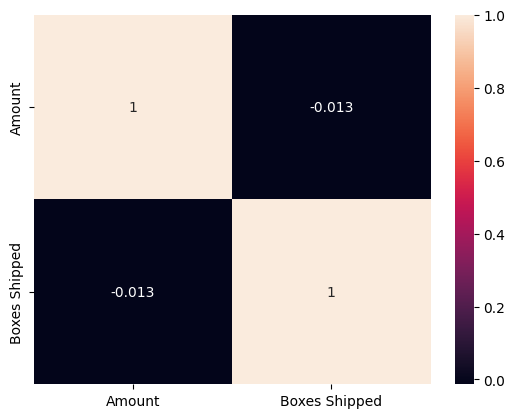

In [ ]:
print(df.info())

# Clean and convert 'Amount' column to numeric
df['Amount'] = df['Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [ ]:
df_clean = df.drop(['Date'], axis=1, errors='ignore')

In [ ]:
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [ ]:
X = df_clean.drop('Boxes Shipped', axis=1) # Sesuaikan nama kolom target
y = df_clean['Boxes Shipped']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.7170582531341092
RMSE: 65.11874568138732


In [ ]:
joblib.dump(model, 'chocolate_model.pkl')
print("Model tersimpan sebagai chocolate_model.pkl")

Model tersimpan sebagai chocolate_model.pkl
